Import Packages (필요한 파이썬 라이브러리 가져오기)

In [1]:
# importing some useful packages
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import cv2
import glob
from collections import deque

# Needed to edit/save/watch video clips
from moviepy import VideoFileClip
from IPython.display import HTML

# Jupyter Notebook 환경이 아니라면 아래 매직 커맨드는 주석 처리해도 무방합니다.
%matplotlib inline

Reading Video (동영상, 테스트용 사진들 폴더에서 읽어오기)

In [2]:
## Reading Video

# Importing videos for processing
project_clip = VideoFileClip("test_videos/project_video.mp4")

# Importing calibration images
cal_filenames = glob.glob('camera_cal/*.jpg')
# 기존 코드의 np.array 말고 리스트로 묶음
cal_images = [plt.imread(img) for img in cal_filenames]

# Importing test images
test_filenames = glob.glob('test_images/*.jpg')
# 기존 코드의 np.array 말고 리스트로 묶음
test_images = [plt.imread(img) for img in test_filenames]

print(f"불러온 캘리브레이션 이미지: {len(cal_images)}장")
print(f"불러온 테스트 이미지: {len(test_images)}장")

불러온 캘리브레이션 이미지: 20장
불러온 테스트 이미지: 8장


Global Parameters (체스판 격자 수, 이미지 자를 때 사용할 기준 좌표 등 코드에서 공통으로 쓸 기본 수치들)

In [3]:
# Chessboard edges
nx = 9
ny = 6

img = test_images[0]
img_y, img_x = (img.shape[0], img.shape[1])
offset = 50

# Lane masking and coordinates for perspective transform
source = np.float32([ # MASK
    [img_y-offset, offset], # bottom left
    [img_y-offset, img_x-offset], # bottom right
    [offset, offset], # top left
    [offset, img_x-offset]]) # top right

dest = np.float32([ # DESTINATION
    [300, 720], # bottom left
    [950, 720], # bottom right
    [300, 0], # top left
    [950, 0]]) # top right

Image Processing (카메라 렌즈는 둥글기 때문에 카메라의 휘어짐 정도를 계산 후, 평평하게 펴주는 작업)

In [4]:
class Camera():    
    def __init__(self):
        # Stores the source 
        self.ret = None
        self.mtx = None
        self.dist = None
        self.rvecs = None
        self.tvecs = None
        
        self.objpoints = [] # 3D points in real space
        self.imgpoints = [] # 2D points in img space
    
        
    def calibrate_camera(self, imgList):
        counter = 0
        for img in imgList:
            # Prepare object points (0,0,0), (1,0,0), etc.
            objp = np.zeros((nx*ny,3), np.float32)
            objp[:,:2] = np.mgrid[0:nx,0:ny].T.reshape(-1,2)

            # Converting to grayscale
            gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

            # Finding chessboard corners
            ret, corners = cv2.findChessboardCorners(gray, (9,6), None)
            if ret == True:
                self.imgpoints.append(corners)
                self.objpoints.append(objp)
                counter += 1
        self.ret, self.mtx, self.dist, self.rvecs, self.tvecs = cv2.calibrateCamera(
            self.objpoints, self.imgpoints, gray.shape[::-1], None, None)
        return self.mtx, self.dist

    
    def undistort(self, img):
        return cv2.undistort(img, self.mtx, self.dist, None, self.mtx)

Camera Calibration 

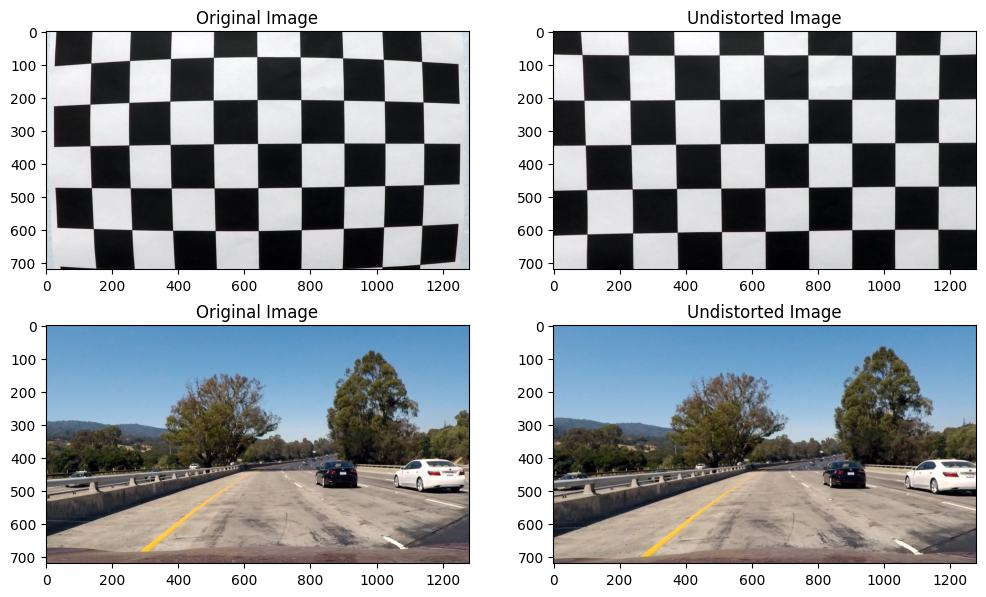

In [5]:
camera = Camera()

# Calibrating for the given camera
mtx, dist = camera.calibrate_camera(cal_images)

img = cv2.imread('camera_cal/calibration1.jpg')
plt.figure(figsize=(12, 7))
plt.subplot(2, 2, 1)
plt.imshow(img)
plt.title("Original Image")
plt.subplot(2, 2, 2)
plt.imshow(cv2.undistort(img, mtx, dist, None, mtx))
plt.title("Undistorted Image")
img = cv2.imread('test_images/test1.jpg')
plt.subplot(2, 2, 3)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.subplot(2, 2, 4)
plt.imshow(cv2.cvtColor(cv2.undistort(img, mtx, dist, None, mtx), cv2.COLOR_BGR2RGB))
plt.title("Undistorted Image")
plt.savefig("output_images/undist_img.jpg")




Masking the Region of Interest (쓸데없는 배경 지우기: 하늘, 나무, 건물 등 윗부분과 양옆부분 까맣게 지움)

In [6]:
def mask_image(image):
    masked_image = np.copy(image)
    mask = np.zeros_like(masked_image)
    vertices = np.array([[source[1], source[0], source[2], source[3]]], dtype=np.int32)
    cv2.fillPoly(mask, vertices, [255,255,255])
    masked_edges = cv2.bitwise_and(masked_image, mask)
    return masked_edges

def test_process(img):
    undist = camera.undistort(img)
    masked = mask_image(undist)
    warped, M, Minv = pers_transform(undist)
    s_bin = hls_thresh(warped)
    b_bin = lab_b_channel(warped, thresh = (185, 255))
    x_bin = sobel_thresh(warped, orient='x', thresh_min=20, thresh_max=100)
    y_bin = sobel_thresh(warped, orient='y', thresh_min=50, thresh_max=150)
    mag_bin = mag_thresh(warped, thresh_min=0, thresh_max=255)
    dir_bin = dir_thresh(warped, thresh_min=0, thresh_max=np.pi/2)
    
    combined = np.zeros_like(x_bin)
    combined[(s_bin==1) | (b_bin == 1)] = 1
    
    return combined, warped, Minv

Image Thresholding (차선만 골라내기: 노란색, 흰색 차선만 골라내고 나머지는 까맣게 지움 & 시점(bird-eye view) 변환)

In [7]:
def pers_transform(img, nx=9, ny=6):
    # Grab the image shape
    img_size = (img.shape[1], img.shape[0])
    src = np.float32([[190, 720], [582, 457], [701, 457], [1145, 720]])
    offset = [150,0]
    dst = np.float32([src[0] + offset, np.array([src[0, 0], 0]) + offset, 
                      np.array([src[3, 0], 0]) - offset, src[3] - offset])
    # Given src and dst points, calculate the perspective transform matrix
    M = cv2.getPerspectiveTransform(src, dst)
    # Warp the image using OpenCV warpPerspective()
    warped = cv2.warpPerspective(img, M, img_size)
    # Return the resulting image and matrix
    Minv = cv2.getPerspectiveTransform(dst, src)

    return warped, M, Minv


def hls_thresh(img, thresh_min=200, thresh_max=255):
    # Convert to HLS color space and separate the S channel
    hls = cv2.cvtColor(img, cv2.COLOR_RGB2HLS)
    s_channel = hls[:,:,1]
    
    # Creating image masked in S channel
    s_binary = np.zeros_like(s_channel)
    s_binary[(s_channel >= thresh_min) & (s_channel <= thresh_max)] = 1
    return s_binary


def sobel_thresh(img, sobel_kernel=3, orient='x', thresh_min=20, thresh_max=100):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    if orient == 'x':
        sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=sobel_kernel)
        abs_sobelx = np.absolute(sobelx)
        scaled_sobel = np.uint8(255*abs_sobelx/np.max(abs_sobelx))
    else:
        sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=sobel_kernel)
        abs_sobely = np.absolute(sobely)
        scaled_sobel = np.uint8(255*abs_sobely/np.max(abs_sobely))
    
    # Creathing img masked in x gradient
    grad_bin = np.zeros_like(scaled_sobel)
    grad_bin[(scaled_sobel >= thresh_min) & (scaled_sobel <= thresh_max)] = 1
    
    return grad_bin


def mag_thresh(img, sobel_kernel=3, thresh_min=100, thresh_max=255):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=sobel_kernel)
    sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=sobel_kernel)
    gradmag = np.sqrt(sobelx**2 + sobely**2)
    scale_factor = np.max(gradmag)/255 
    gradmag = (gradmag/scale_factor).astype(np.uint8) 
    binary_output = np.zeros_like(gradmag)
    binary_output[(gradmag >= thresh_min) & (gradmag <= thresh_max)] = 1
    return binary_output


def dir_thresh(img, sobel_kernel=3, thresh_min=0, thresh_max=np.pi/2):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=sobel_kernel)
    sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=sobel_kernel)
    absgraddir = np.arctan2(np.absolute(sobely), np.absolute(sobelx))
    binary_output =  np.zeros_like(absgraddir)
    binary_output[(absgraddir >= thresh_min) & (absgraddir <= thresh_max)] = 1
    return binary_output


def lab_b_channel(img, thresh=(190,255)):
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2Lab)
    lab_b = lab[:,:,2]
    if np.max(lab_b) > 175:
        lab_b = lab_b*(255/np.max(lab_b))
    binary_output = np.zeros_like(lab_b)
    binary_output[((lab_b > thresh[0]) & (lab_b <= thresh[1]))] = 1
    return binary_output

Warping and Processing Check (중간 점검 1: 위에서 만든 필터들과 시점 변환이 예쁘게 잘 먹혔는지 사진 띄워서 확인)

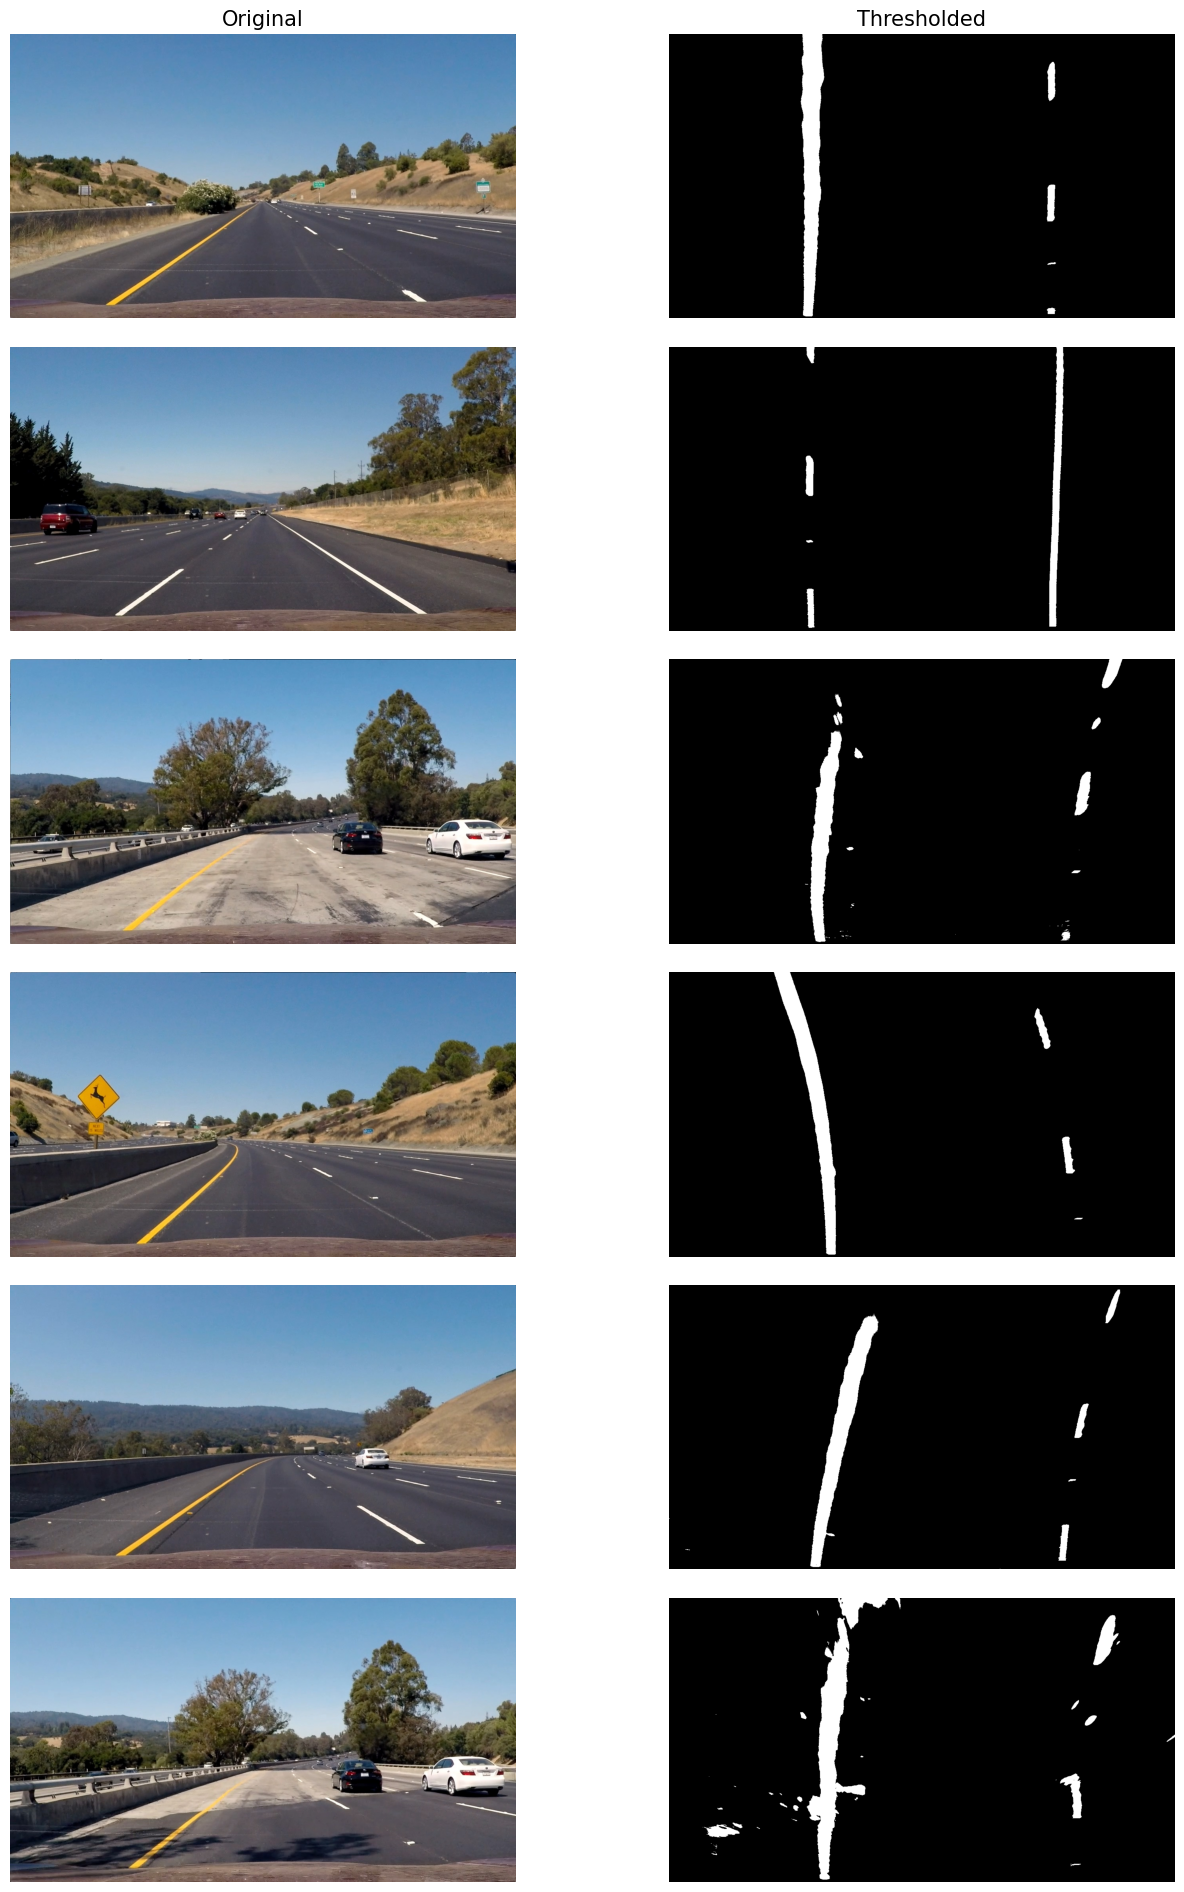

In [8]:
test_images_thresholded= []

fig, ax = plt.subplots(6, 2, figsize=(17,24))
fig.subplots_adjust(hspace=0.1, wspace=0)
ax[0][0].set_title('Original', fontsize=15)
ax[0][1].set_title('Thresholded', fontsize=15)

for i in range(6) :
    ax[i,0].imshow(test_images[i])
    thresholded_img, warped, Minv = test_process(test_images[i])
    test_images_thresholded.append(thresholded_img)
    ax[i,1].imshow(thresholded_img,cmap='gray')
for axes in ax.flatten() :
    axes.axis('off')
plt.savefig("output_images/warp_processing_check.jpg")

Window Searching (차선 추적하기: bird-eye view로 바꾼 까만 화면에서 흰색 선들이 어디에 모여있는지 확인. 화면 맨 밑바닥부터 작은 네모 상자(Window)를 블록 쌓듯이 위로 쌓아 올리면서 차선의 궤적을 따라감.)

In [ ]:
def window_search(binary_warped):
    bottom_half_y = binary_warped.shape[0] // 2
    histogram = np.sum(binary_warped[bottom_half_y:,:], axis=0)
    out_img = np.dstack((binary_warped, binary_warped, binary_warped))*255
    
    # [수정] np.int -> int
    midpoint = int(histogram.shape[0] // 2)
    leftx_base = np.argmax(histogram[:midpoint])
    rightx_base = np.argmax(histogram[midpoint:]) + midpoint

    nwindows = 9
    # [수정] np.int -> int
    window_height = int(binary_warped.shape[0] // nwindows)
    
    nonzero = binary_warped.nonzero()
    nonzeroy = np.array(nonzero[0])
    nonzerox = np.array(nonzero[1])
    
    leftx_current = leftx_base
    rightx_current = rightx_base
    margin = 100
    minpix = 50
    left_lane_inds = []
    right_lane_inds = []

    for window in range(nwindows):
        win_y_low = binary_warped.shape[0] - (window+1)*window_height
        win_y_high = binary_warped.shape[0] - window*window_height
        win_xleft_low = leftx_current - margin
        win_xleft_high = leftx_current + margin
        win_xright_low = rightx_current - margin
        win_xright_high = rightx_current + margin
        
        cv2.rectangle(out_img,(win_xleft_low,win_y_low),(win_xleft_high,win_y_high),(0,255,0), 2) 
        cv2.rectangle(out_img,(win_xright_low,win_y_low),(win_xright_high,win_y_high),(0,255,0), 2) 
        
        good_left_inds = ((nonzeroy >= win_y_low) & (nonzeroy < win_y_high) & 
                          (nonzerox >= win_xleft_low) & (nonzerox < win_xleft_high)).nonzero()[0]
        good_right_inds = ((nonzeroy >= win_y_low) & (nonzeroy < win_y_high) & 
                           (nonzerox >= win_xright_low) & (nonzerox < win_xright_high)).nonzero()[0]
        
        left_lane_inds.append(good_left_inds)
        right_lane_inds.append(good_right_inds)
        
        # [수정] np.int -> int
        if len(good_left_inds) > minpix:
            leftx_current = int(np.mean(nonzerox[good_left_inds]))
        if len(good_right_inds) > minpix:        
            rightx_current = int(np.mean(nonzerox[good_right_inds]))

    left_lane_inds = np.concatenate(left_lane_inds)
    right_lane_inds = np.concatenate(right_lane_inds)

    leftx = nonzerox[left_lane_inds]
    lefty = nonzeroy[left_lane_inds] 
    rightx = nonzerox[right_lane_inds]
    righty = nonzeroy[right_lane_inds] 

    left_fit = np.polyfit(lefty, leftx, 2)
    right_fit = np.polyfit(righty, rightx, 2)

    ploty = np.linspace(0, binary_warped.shape[0]-1, binary_warped.shape[0] )
    left_fitx = left_fit[0]*ploty**2 + left_fit[1]*ploty + left_fit[2]
    right_fitx = right_fit[0]*ploty**2 + right_fit[1]*ploty + right_fit[2]
    
    out_img[nonzeroy[left_lane_inds], nonzerox[left_lane_inds]] = [1, 0, 0]
    out_img[nonzeroy[right_lane_inds], nonzerox[right_lane_inds]] = [0, 0, 1]
        
    right = np.asarray(tuple(zip(right_fitx, ploty)), np.int32)
    left = np.asarray(tuple(zip(left_fitx, ploty)), np.int32)
    cv2.polylines(out_img, [right], False, (1,1,0), thickness=5)
    cv2.polylines(out_img, [left], False, (1,1,0), thickness=5)
    
    return left_lane_inds, right_lane_inds, out_img

Margin Search (1초 전 화면에서 차선에 박스를 만들었다면, 굳이 전체를 찾을 필요 없이 1초전에 찾은 차선 근처(마진)만 빠르게 찾아 컴퓨터 계산 부담을 덜어주는 기술)

In [10]:
def margin_search(binary_warped):
    nonzero = binary_warped.nonzero()
    nonzeroy = np.array(nonzero[0])
    nonzerox = np.array(nonzero[1])
    margin = 30

    left_lane_inds = ((nonzerox > (left_line.current_fit[0]*(nonzeroy**2) + left_line.current_fit[1]*nonzeroy + left_line.current_fit[2] - margin)) & 
                      (nonzerox < (left_line.current_fit[0]*(nonzeroy**2) + left_line.current_fit[1]*nonzeroy + left_line.current_fit[2] + margin))) 
    right_lane_inds = ((nonzerox > (right_line.current_fit[0]*(nonzeroy**2) + right_line.current_fit[1]*nonzeroy + right_line.current_fit[2] - margin)) & 
                       (nonzerox < (right_line.current_fit[0]*(nonzeroy**2) + right_line.current_fit[1]*nonzeroy + right_line.current_fit[2] + margin)))  

    leftx = nonzerox[left_lane_inds]
    lefty = nonzeroy[left_lane_inds] 
    rightx = nonzerox[right_lane_inds]
    righty = nonzeroy[right_lane_inds]
    
    left_fit = np.polyfit(lefty, leftx, 2)
    right_fit = np.polyfit(righty, rightx, 2)
    
    ploty = np.linspace(0, binary_warped.shape[0]-1, binary_warped.shape[0] )
    left_fitx = left_fit[0]*ploty**2 + left_fit[1]*ploty + left_fit[2]
    right_fitx = right_fit[0]*ploty**2 + right_fit[1]*ploty + right_fit[2]
    
    out_img = np.dstack((binary_warped, binary_warped, binary_warped))*255
    window_img = np.zeros_like(out_img)

    left_line_window1 = np.array([np.transpose(np.vstack([left_fitx-margin, ploty]))])
    left_line_window2 = np.array([np.flipud(np.transpose(np.vstack([left_fitx+margin, ploty])))])
    left_line_pts = np.hstack((left_line_window1, left_line_window2))
    right_line_window1 = np.array([np.transpose(np.vstack([right_fitx-margin, ploty]))])
    right_line_window2 = np.array([np.flipud(np.transpose(np.vstack([right_fitx+margin, ploty])))])
    right_line_pts = np.hstack((right_line_window1, right_line_window2))

    # Python 3.10 Fix: np.intc -> np.int32
    cv2.fillPoly(window_img, np.int32([left_line_pts]), (0,255,0))
    cv2.fillPoly(window_img, np.int32([right_line_pts]), (0,255,0))
    out_img = cv2.addWeighted(out_img, 1, window_img, 0.3, 0)

    out_img[nonzeroy[left_lane_inds], nonzerox[left_lane_inds]] = [1, 0, 0]
    out_img[nonzeroy[right_lane_inds], nonzerox[right_lane_inds]] = [0, 0, 1]
        
    right = np.asarray(tuple(zip(right_fitx, ploty)), np.int32)
    left = np.asarray(tuple(zip(left_fitx, ploty)), np.int32)
    cv2.polylines(out_img, [right], False, (1,1,0), thickness=5)
    cv2.polylines(out_img, [left], False, (1,1,0), thickness=5)
    
    return left_lane_inds, right_lane_inds, out_img

Window Search Check (중간 점검2: 상자 쌓아 올리면서 차선 잘 찾아냈는지 그림으로 그려서 확인)

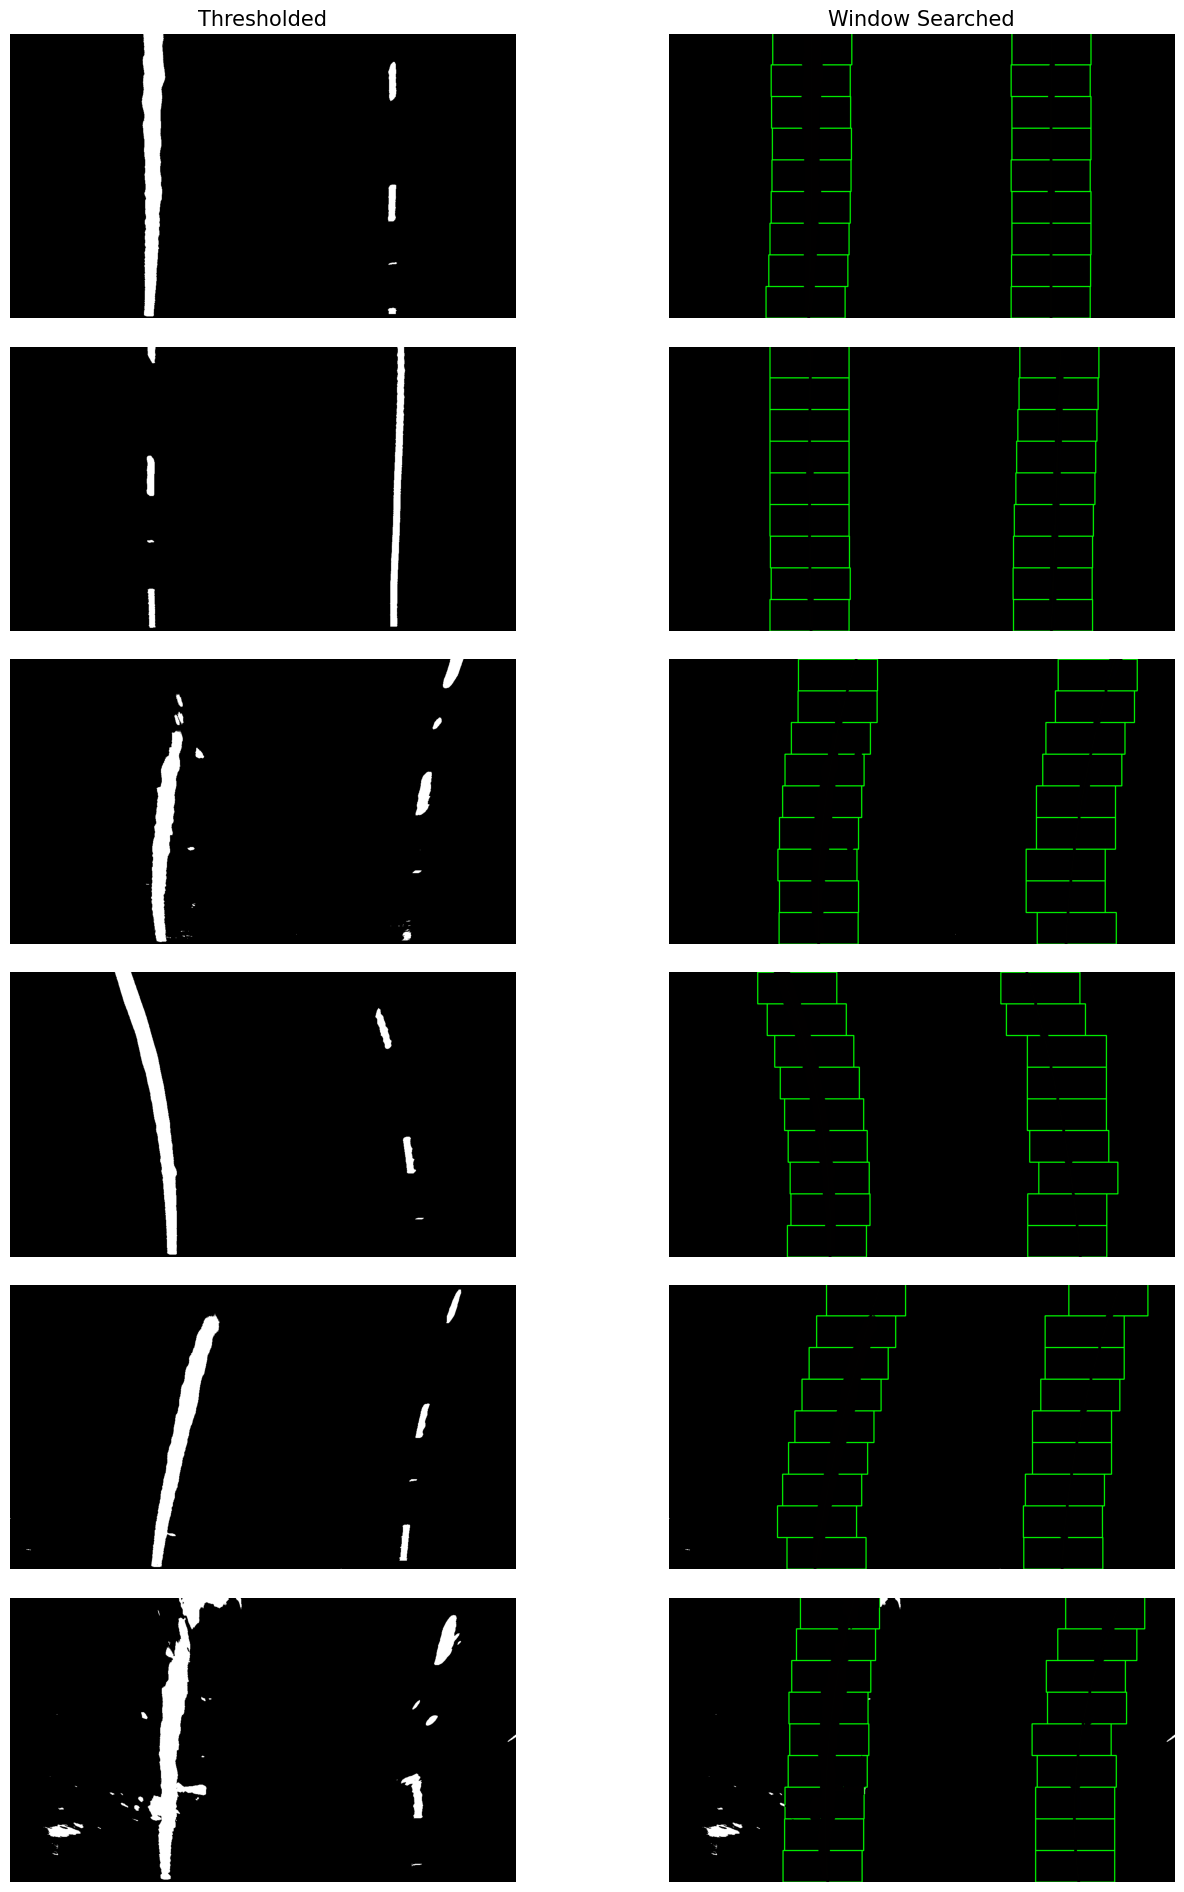

In [11]:
fig, ax = plt.subplots(6, 2, figsize=(17,24))
fig.subplots_adjust(hspace=0.1, wspace=0)
ax[0][0].set_title('Thresholded', fontsize=15)
ax[0][1].set_title('Window Searched', fontsize=15)

for i in range(6) :
    thresholded_img, warped, Minv = test_process(test_images[i])
    ax[i,0].imshow(thresholded_img, cmap='gray')
    left, right, polynom_img = window_search(thresholded_img)
    ax[i,1].imshow(polynom_img)
for axes in ax.flatten() :
    axes.axis('off')
plt.savefig("output_images/polynom_windows.jpg")

Line Class (차가 얼마나 휘었는지 곡률, 차가 중앙에서 얼마나 벗어났는지 등, 계산된 중요한 정보들을 저장해두고 다음 프레임으로 엄겨주는 보관함 역할)

In [12]:
class Line():
    def __init__(self, maxSamples=4):
        self.maxSamples = maxSamples 
        self.recent_xfitted = deque(maxlen=self.maxSamples)
        self.current_fit = [np.array([False])]  
        self.best_fit = None  
        self.bestx = None
        self.detected = False 
        self.radius_of_curvature = None 
        self.line_base_pos = None 
         
    def update_lane(self, ally, allx):
        self.bestx = np.mean(allx, axis=0)
        new_fit = np.polyfit(ally, allx, 2)
        self.current_fit = new_fit
        self.recent_xfitted.append(self.current_fit)
        self.best_fit = np.mean(self.recent_xfitted, axis=0)
        
        ym_per_pix = 30/720
        xm_per_pix = 3.7/700
        fit_cr = np.polyfit(ally*ym_per_pix, allx*xm_per_pix, 2)
        y_eval = np.max(ally)
        self.radius_of_curvature = ((1 + (2*fit_cr[0]*y_eval*ym_per_pix + fit_cr[1])**2)**1.5) / np.absolute(2*fit_cr[0])

Lane Validation (이상한 데이터 걸러내기: 햇빛에 반사되거나 그림자 때문에 차선이 말도 안되게 넓어보인다면 무시하는 안전장치)

In [13]:
def validate_lane_update(img, left_lane_inds, right_lane_inds):
    img_size = (img.shape[1], img.shape[0])
    
    nonzero = img.nonzero()
    nonzeroy = np.array(nonzero[0])
    nonzerox = np.array(nonzero[1])
    
    left_line_allx = nonzerox[left_lane_inds]
    left_line_ally = nonzeroy[left_lane_inds] 
    right_line_allx = nonzerox[right_lane_inds]
    right_line_ally = nonzeroy[right_lane_inds]
    
    if len(left_line_allx) <= 1800 or len(right_line_allx) <= 1800:
        left_line.detected = False
        right_line.detected = False
        return
    
    left_x_mean = np.mean(left_line_allx, axis=0)
    right_x_mean = np.mean(right_line_allx, axis=0)
    lane_width = np.subtract(right_x_mean, left_x_mean)
    
    if left_x_mean > 740 or right_x_mean < 740:
        left_line.detected = False
        right_line.detected = False
        return
    
    if  lane_width < 300 or lane_width > 800:
        left_line.detected = False
        right_line.detected = False
        return 
    
    if left_line.bestx is None or np.abs(np.subtract(left_line.bestx, np.mean(left_line_allx, axis=0))) < 100:
        left_line.update_lane(left_line_ally, left_line_allx)
        left_line.detected = True
    else:
        left_line.detected = False
        
    if right_line.bestx is None or np.abs(np.subtract(right_line.bestx, np.mean(right_line_allx, axis=0))) < 100:
        right_line.update_lane(right_line_ally, right_line_allx)
        right_line.detected = True
    else:
        right_line.detected = False   
 
    xm_per_pix = 3.7/610 
    car_position = img_size[0]/2
    l_fit = left_line.current_fit
    r_fit = right_line.current_fit
    left_lane_base_pos = l_fit[0]*img_size[1]**2 + l_fit[1]*img_size[1] + l_fit[2]
    right_lane_base_pos = r_fit[0]*img_size[1]**2 + r_fit[1]*img_size[1] + r_fit[2]
    lane_center_position = (left_lane_base_pos + right_lane_base_pos) / 2
    left_line.line_base_pos = (car_position - lane_center_position) * xm_per_pix + 0.2
    right_line.line_base_pos = left_line.line_base_pos

Lane Drawing and Stats (최종적으로 찾아낸 차선을 다시 원래 운전자 시점으로 되돌리고, 초록색 카펫을 깔아주고, 차량이 중앙에서 몇cm 쏠려있는지 화면 구석에 수치로 띄워줌)

In [ ]:
def find_lanes(img):
    if left_line.detected and right_line.detected:
        left_lane_inds, right_lane_inds, out_img = margin_search(img)
        validate_lane_update(img, left_lane_inds, right_lane_inds)
    else:
        left_lane_inds, right_lane_inds, out_img = window_search(img)
        validate_lane_update(img, left_lane_inds, right_lane_inds)
    return out_img


def write_stats(img):
    font = cv2.FONT_HERSHEY_PLAIN
    size = 3
    weight = 2
    color = (255,255,255)
    
    radius_of_curvature = (right_line.radius_of_curvature + left_line.radius_of_curvature) / 2
    
    # [수정] f-string 적용
    cv2.putText(img, f'Lane Curvature Radius: {radius_of_curvature:.2f}m', (30,60), font, size, color, weight)

    if (left_line.line_base_pos >= 0):
        cv2.putText(img, f'Vehicle is {left_line.line_base_pos*100:.2f}cm Right of Center', (30,100), font, size, color, weight)
    else:
        cv2.putText(img, f'Vehicle is {abs(left_line.line_base_pos)*100:.2f}cm Left of Center', (30,100), font, size, color, weight)
        
        
def draw_lane(undist, img, Minv):
    ploty = np.linspace(0, undist.shape[0] - 1, undist.shape[0])
    warp_zero = np.zeros_like(img).astype(np.uint8)
    color_warp = np.stack((warp_zero, warp_zero, warp_zero), axis=-1)

    left_fit = left_line.best_fit
    right_fit = right_line.best_fit
    
    if left_fit is not None and right_fit is not None:
        left_fitx = left_fit[0]*ploty**2 + left_fit[1]*ploty + left_fit[2]
        pts_left = np.array([np.transpose(np.vstack([left_fitx, ploty]))])
        
        right_fitx = right_fit[0]*ploty**2 + right_fit[1]*ploty + right_fit[2]
        pts_right = np.array([np.flipud(np.transpose(np.vstack([right_fitx, ploty])))])
        pts = np.hstack((pts_left, pts_right))
        
        # [수정] np.int_ -> np.int32
        cv2.fillPoly(color_warp, np.int32([pts]), (64, 224, 208))
        
        newwarp = cv2.warpPerspective(color_warp, Minv, (img.shape[1], img.shape[0])) 
        result = cv2.addWeighted(undist, 1, newwarp, 0.6, 0)
        write_stats(result)
        return result
    return undist

def assemble_img(warped, threshold_img, polynomial_img, lane_img):
    img_out = np.zeros((720,1707,3), dtype=np.uint8)
    img_out[0:720,0:1280,:] = lane_img
    
    fontScale = 1
    thickness = 1
    fontFace = cv2.FONT_HERSHEY_PLAIN
    
    img_out[0:240,1281:1707,:] = cv2.resize(warped,(426,240))
    boxsize, _ = cv2.getTextSize("Transformed", fontFace, fontScale, thickness)
    cv2.putText(img_out, "Transformed", (int(1494-boxsize[0]/2),40), fontFace, fontScale,(255,255,255), thickness,  lineType = cv2.LINE_AA)
   
    resized = cv2.resize(threshold_img,(426,240))
    resized = np.uint8(resized)
    gray_image = cv2.cvtColor(resized*255,cv2.COLOR_GRAY2RGB)
    img_out[241:481,1281:1707,:] = cv2.resize(gray_image,(426,240))
    boxsize, _ = cv2.getTextSize("Filtered", fontFace, fontScale, thickness)
    cv2.putText(img_out, "Filtered", (int(1494-boxsize[0]/2),281), fontFace, fontScale,(255,255,255), thickness,  lineType = cv2.LINE_AA)
 
    img_out[480:720,1281:1707,:] = cv2.resize(polynomial_img*255,(426,240))
    boxsize, _ = cv2.getTextSize("Detected Lanes", fontFace, fontScale, thickness)
    cv2.putText(img_out, "Detected Lanes", (int(1494-boxsize[0]/2),521), fontFace, fontScale,(255,255,255), thickness,  lineType = cv2.LINE_AA)
    
    return img_out

Final Pipeline(위에서 만든 모든 기능 (왜곡 펴기 -> 시점 변환 -> 차선 찾기 -> 색칠하기)을 하나의 컨베이어 벨트처럼 연결 후, 원본 동영상을 바탕으로 새 동영상 만들어줌.)

...
MoviePy - Building video project_result.mp4.
MoviePy - Writing video project_result.mp4



MoviePy - Done !
MoviePy - video ready project_result.mp4


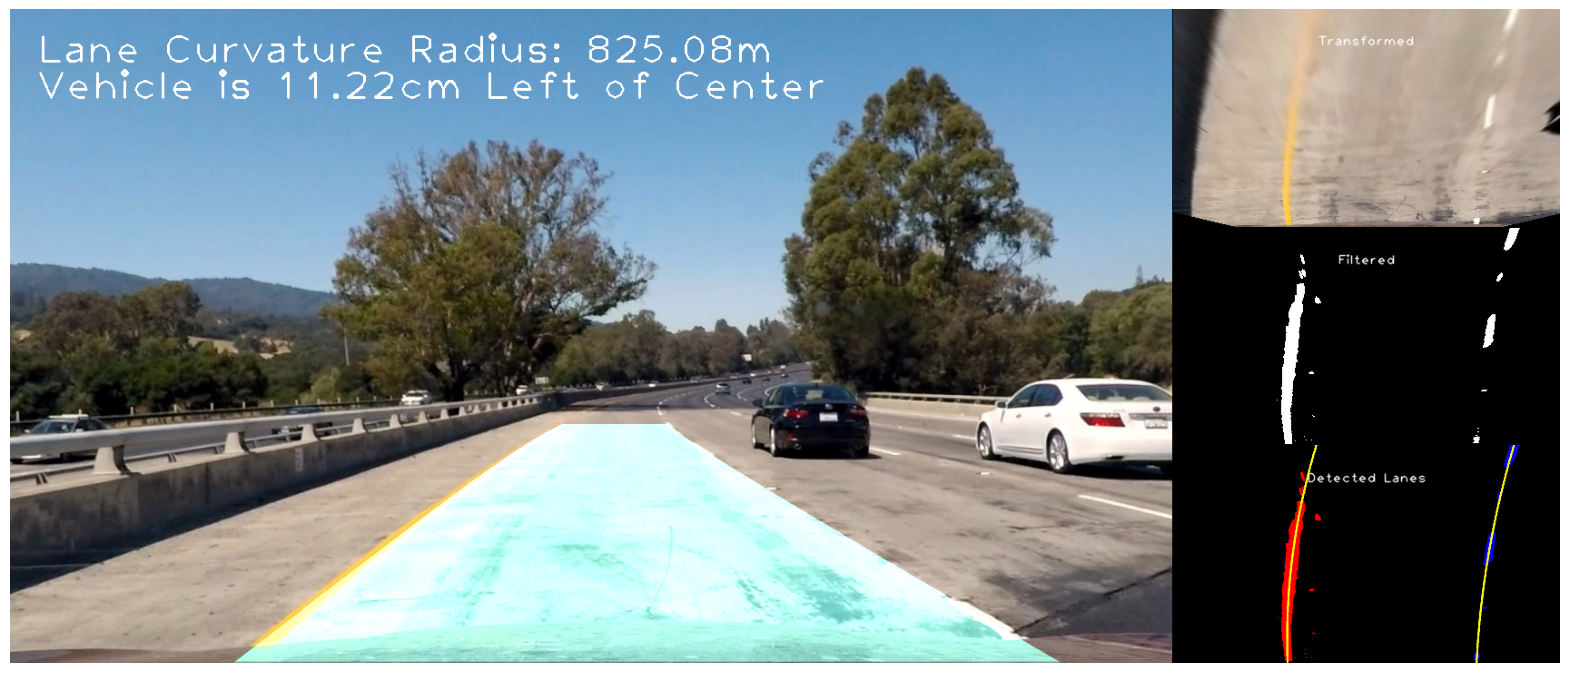

In [ ]:
def process_img(img):
    undist = camera.undistort(img)
    masked = mask_image(undist)
    warped, M, Minv = pers_transform(undist)
    s_bin = hls_thresh(warped)
    b_bin = lab_b_channel(warped, thresh = (185, 255))
    
    combined = np.zeros_like(s_bin)
    combined[(s_bin==1) | (b_bin == 1)] = 1
    
    output_img = find_lanes(combined)
    lane_img = draw_lane(undist, combined, Minv)   
    result = assemble_img(warped, combined, output_img, lane_img)    
    
    return result

left_line = Line()
right_line = Line()

plt.figure(figsize = (20,20))
plt.imshow(process_img(test_images[2]))
plt.axis('off')
print("...")
plt.savefig("output_images/assembled_img.jpg")

# Initialize Left and Right Lanes
left_line = Line()
right_line = Line()

# Reset and Calibrate
video_result = 'project_result.mp4'
# [수정] fl_image 대신 최신 규격인 image_transform을 사용
project_video_clip = project_clip.image_transform(process_img)
project_video_clip.write_videofile(video_result, audio=False)